
# HEALTHCARE READMISSION ANALYTICS PROJECT
- Author: Raghvendra Sharma
- Purpose: End-to-end analysis of hospital readmissions using diabetes patient data

This script demonstrates:
1. Data acquisition from public sources
2. Data preprocessing and cleaning
3. Exploratory data analysis
4. Predictive modeling
5. Results visualization and reporting

#### Key Expectations: Build predictive model for 30-day readmissions,create visualizations showing risk fac and document complete analysis workflow on GitHub with executive summary


##  ENVIRONMENT SETUP AND LIBRARY IMPORTS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

import warnings
import os
from datetime import datetime

# Configuration settings
warnings.filterwarnings('ignore')  # Suppress warnings for cleaner output
pd.set_option('display.max_columns', None)  # Display all columns(restrict features truncade(..) 50 columns are there)
pd.set_option('display.max_rows', 100)  # Display up to 100 rows
plt.style.use('seaborn-v0_8-darkgrid')  # Set consistent plot style(global aesthetic theme)

# Set random seed for reproducibility
np.random.seed(42)


##  DATA ACQUISITION


We'll download the Diabetes 130-US Hospitals dataset from UCI ML Repository.
This dataset contains 10 years of hospital admission records for diabetes patients.

Dataset characteristics:
- 101,766 hospital admissions
- ~50 features (patient demographics, diagnoses, medications, procedures)
- Target variable: Readmission status




In [2]:

# Define data URL - UCI Machine Learning Repository
DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00296/dataset_diabetes.zip"

data_file = '/content/diabetic_data.csv'

# Load the dataset
df_raw = pd.read_csv(data_file)
print('Data Loaded Sucessfully')
print(f"  - Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"  - Memory usage: {df_raw.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Display basic information about the dataset
print("\n" + "-" * 80)
print("INITIAL DATA PREVIEW")
print("-" * 80)
print("\nFirst 5 rows:")
print(df_raw.head())

print("\n\nDataset Info:")
print(df_raw.info())

print("\n\nBasic Statistics:")
print(df_raw.describe())

Data Loaded Sucessfully
  - Shape: 101,766 rows × 50 columns
  - Memory usage: 192.87 MB

--------------------------------------------------------------------------------
INITIAL DATA PREVIEW
--------------------------------------------------------------------------------

First 5 rows:
   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)      ?   
1        149190     55629189        Caucasian  Female  [10-20)      ?   
2         64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3        500364     82442376        Caucasian    Male  [30-40)      ?   
4         16680     42519267        Caucasian    Male  [40-50)      ?   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1              

## DATA QUALITY ASSESSMENT

Before any analysis, we must understand data quality issues:
1. Missing values
2. Duplicate records
3. Data types
4. Value distributions
5. Outliers

This step is CRITICAL - poor data quality leads to poor insights!





--- DATA QUALITY SUMMARY ---
Total Rows: 101,766 | Duplicates: 0 (0.00%)

Missing Values (NaN):
max_glu_serum    96420
A1Cresult        84748

Placeholder Counts (across common indicators):
weight               98569
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21

Target ('readmitted') Distribution:
            Count  Pct (%)
readmitted                
NO          54864    53.91
>30         35545    34.93
<30         11357    11.16
✓ Created 'visualizations' directory for output


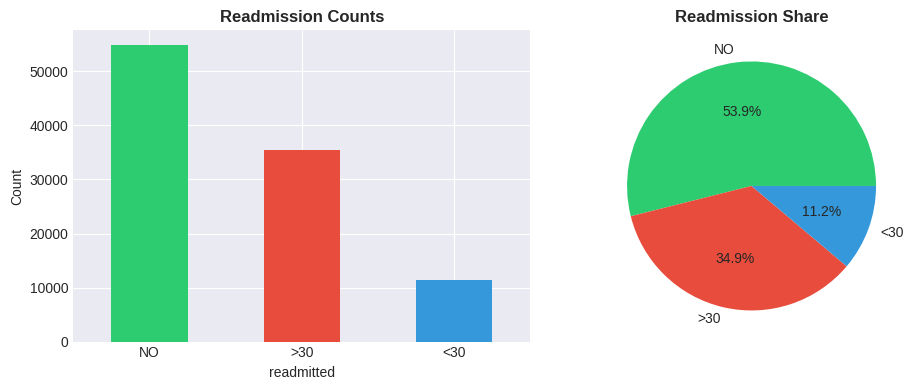

In [3]:
# 1. Setup & Duplicates
df = df_raw.copy()
n_rows = len(df)
n_dup = df.duplicated().sum()

print("--- DATA QUALITY SUMMARY ---")
print(f"Total Rows: {n_rows:,} | Duplicates: {n_dup:,} ({n_dup/n_rows:.2%})")

# 2. Missing Values (NaN)
null_s = df.isnull().sum()
null_s = null_s[null_s > 0]
print("\nMissing Values (NaN):")
print(null_s.to_string() if not null_s.empty else "None") # if Missing values exist print them with there columns and number

# 3. Placeholder Values Check (Scanning for '?', 'Unknown', 'NA', etc.)
placeholders = ['?', 'Unknown', 'unknown', 'N/A', 'NA', 'null', 'None', '', ' ']

q_s = df.select_dtypes(include='object').isin(placeholders).sum()
q_s = q_s[q_s > 0].sort_values(ascending=False)

print("\nPlaceholder Counts (across common indicators):")
print(q_s.to_string() if not q_s.empty else "None")

# 4. Target Distribution
print("\nTarget ('readmitted') Distribution:")
target_dist = df['readmitted'].value_counts()
print(pd.DataFrame({'Count': target_dist, 'Pct (%)': (target_dist / n_rows * 100).round(2)}))

# 5. Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
colors = ['#2ecc71', '#e74c3c', '#3498db']

target_dist.plot(kind='bar', ax=ax1, color=colors, rot=0)
ax1.set_title('Readmission Counts', fontweight='bold')
ax1.set_ylabel('Count')

ax2.pie(target_dist.values, labels=target_dist.index, autopct='%1.1f%%', colors=colors)
ax2.set_title('Readmission Share', fontweight='bold')

plt.tight_layout()
# saving the graph in png
os.makedirs("visualizations", exist_ok=True)
print("✓ Created 'visualizations' directory for output")
plt.savefig('visualizations/01_target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


##  DATA CLEANING AND PREPROCESSING



Based on our quality assessment, we'll now clean the data:
1. Handle missing/placeholder values
2. Remove unnecessary columns
3. Convert data types
4. Create binary target variable (for modeling simplification)


In [4]:

# Replace '?' with NaN for consistent missing value handling
print("\n1. REPLACING PLACEHOLDER VALUES")
print("-" * 80)
df = df.replace('?', np.nan)
print("✓ Replaced all '?' with NaN (proper missing value indicator)")

# Drop columns with excessive missing data or low predictive value
print("\n2. REMOVING PROBLEMATIC COLUMNS")
print("-" * 80)

# Columns to drop (based on domain knowledge and missing data analysis)
columns_to_drop = [
    'encounter_id',  # Identifier, not predictive
    'patient_nbr',   # Identifier, not predictive
    'weight',        # 97% missing
    'payer_code',    # 40% missing, many categories
    'medical_specialty',  # 50% missing
    'A1Cresult',      # Too many values are nan and not used in the model
    'max_glu_serum'    # Too many values are nan and not used in the model
]

df = df.drop(columns=columns_to_drop, errors='ignore')

print(f"\n✓ New dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

# Handle remaining missing values
print("\n3. HANDLING REMAINING MISSING VALUES")
print("-" * 80)

## For race, diagnosis codes: fill with 'Unknown'
categorical_fill_cols = ['race', 'diag_1', 'diag_2', 'diag_3']

for col in categorical_fill_cols:
    if col in df.columns:
        missing_before = df[col].isnull().sum()
        df[col] = df[col].fillna('Unknown')
        print(f"  - {col}: Filled {missing_before:,} missing values with 'Unknown'")

print("✓ Categorical missing values handled")





DATA CLEANING AND PREPROCESSING

1. REPLACING PLACEHOLDER VALUES
--------------------------------------------------------------------------------
✓ Replaced all '?' with NaN (proper missing value indicator)

2. REMOVING PROBLEMATIC COLUMNS
--------------------------------------------------------------------------------

✓ New dataset shape: 101,766 rows × 43 columns

3. HANDLING REMAINING MISSING VALUES
--------------------------------------------------------------------------------
  - race: Filled 2,273 missing values with 'Unknown'
  - diag_1: Filled 21 missing values with 'Unknown'
  - diag_2: Filled 358 missing values with 'Unknown'
  - diag_3: Filled 1,423 missing values with 'Unknown'
✓ Categorical missing values handled


In [5]:
# checking the value counts of the 'readmitted' column
df['readmitted'].value_counts()

,count
readmitted,
NO,54864
>30,35545
<30,11357


3 categories existed

**Convert Target Variable (`readmitted`) to Binary**

**Why are we doing this?**

The original dataset categorizes readmissions into three classes:
- `<30` (Readmitted within 30 days)
- `>30` (Readmitted after 30 days)
- `NO` (Never readmitted)

For our core predictive task, we want to flag **high-risk patients who need urgent intervention**. Hospitals specifically focus on 30-day readmissions due to clinical urgency and Medicare financial penalties.

**Target Mapping:**
- **`<30` → `1` (High Risk / Early Readmission)**
- **`>30` & `NO` → `0` (Low Risk / No Early Readmission)**

Converting this into a binary target simplifies model evaluation and allows us to calculate the **class imbalance ratio** for better model selection.

In [6]:
# Create binary target variable (1 for <30 days, 0 otherwise)
df["readmitted_binary"] = (df["readmitted"] == "<30").astype(int)

# Print distribution and class imbalance ratio
counts = df["readmitted_binary"].value_counts()
pcts = (counts / len(df) * 100).round(2)
imbalance_ratio = counts[0] / counts[1]

print("Target Variable Distribution:")
print(f"  Class 0 (Low Risk):  {counts[0]:,} ({pcts[0]}%)")
print(f"  Class 1 (High Risk): {counts[1]:,} ({pcts[1]}%)")
print(f"Class Imbalance Ratio: {imbalance_ratio:.2f}:1")

Target Variable Distribution:
  Class 0 (Low Risk):  90,409 (88.84%)
  Class 1 (High Risk): 11,357 (11.16%)
Class Imbalance Ratio: 7.96:1


### Feature Engineering — Grouping ICD-9 Diagnosis Codes**

**Why are we doing this?**
The raw dataset contains hundreds of specific ICD-9 medical diagnosis codes across three primary diagnostic columns (`diag_1`, `diag_2`, `diag_3`). Using these raw codes directly would create hundreds of sparse, high-cardinality features after One-Hot Encoding, leading to overfitting and memory overhead.

**Clinical categories created:** To make the data clinically meaningful and cleaner for machine learning models, we map the numeric ranges to 10 high-level categories:

1. Circulatory (Heart & vascular conditions)
2. Respiratory (Lung & breathing conditions)
3. Digestive (Gastrointestinal conditions)
4. Diabetes
5. Injury (Trauma & poisoning)
6. Musculoskeletal (Bone, joint & muscle conditions)
7. Genitourinary (Kidney & bladder conditions)
8. Neoplasms (Cancers & tumors)
9. Other (Supplemental V/E codes, or any code outside the 8 ranges above)
10. Unknown (Value was already missing before this step ran)

**Why some conditions use `or`(e.g., `code == 785`):** ICD-9 reserves specific "symptom codes" for cases where a diagnosis is recorded as a symptom rather than a confirmed disease — common when a patient is admitted before a doctor pins down the exact cause. These fall numerically outside the main disease range but clinically belong with that organ system, so four ranges also check for their matching symptom code: `785` with Circulatory, `786` with Respiratory, `787` with Digestive, `788` with Genitourinary. Without this, a patient admitted for "chest pain" would land in `Other` instead of `Circulatory`.

In [7]:
# Feature Engineering - Group ICD-9 Diagnosis Codes into Clinical Categories


def categorize_diagnosis(diag_code):
    """Map raw ICD-9 diagnosis codes into 10 clinical categories."""

    # 1. Handle missing or predefined 'Unknown' values
    if pd.isna(diag_code) or diag_code == "Unknown":
        return "Unknown"

    diag_str = str(diag_code)

    # 2. Supplementary ICD-9 codes starting with 'V'(supplementary health factors, e.g., routine checkups) or 'E'(external causes of injury, e.g., accidents)
    if diag_str.startswith("V") or diag_str.startswith("E"):
        return "Other"

    # 3. Numeric range check
    try:
        code = float(diag_str)

        if 390 <= code <= 459 or code == 785:
            return "Circulatory"
        elif 460 <= code <= 519 or code == 786:
            return "Respiratory"
        elif 520 <= code <= 579 or code == 787:
            return "Digestive"
        elif 250 <= code < 251:
            return "Diabetes"
        elif 800 <= code <= 999:
            return "Injury"
        elif 710 <= code <= 739:
            return "Musculoskeletal"
        elif 580 <= code <= 629 or code == 788:
            return "Genitourinary"
        elif 140 <= code <= 239:
            return "Neoplasms"
        else:
            return "Other"

    # Catch any unexpected formatting or unparseable text strings
    except ValueError:
        return "Other"


# Apply the categorization across primary, secondary, and tertiary diagnosis columns
for diag_col in ["diag_1", "diag_2", "diag_3"]:
    if diag_col in df.columns:
        new_col_name = f"{diag_col}_category"
        df[new_col_name] = df[diag_col].apply(categorize_diagnosis)

        print(f"✓ Created {new_col_name}")
        print(f"  Distribution: {df[new_col_name].value_counts().to_dict()}\n")

print("✓ Feature engineering complete!")

✓ Created diag_1_category
  Distribution: {'Circulatory': 30437, 'Other': 18172, 'Respiratory': 14423, 'Digestive': 9475, 'Diabetes': 8757, 'Injury': 6974, 'Genitourinary': 5117, 'Musculoskeletal': 4957, 'Neoplasms': 3433, 'Unknown': 21}

✓ Created diag_2_category
  Distribution: {'Circulatory': 31881, 'Other': 26553, 'Diabetes': 12794, 'Respiratory': 10895, 'Genitourinary': 8376, 'Digestive': 4170, 'Neoplasms': 2547, 'Injury': 2428, 'Musculoskeletal': 1764, 'Unknown': 358}

✓ Created diag_3_category
  Distribution: {'Circulatory': 30306, 'Other': 29195, 'Diabetes': 17157, 'Respiratory': 7358, 'Genitourinary': 6680, 'Digestive': 3930, 'Injury': 1946, 'Musculoskeletal': 1915, 'Neoplasms': 1856, 'Unknown': 1423}

✓ Feature engineering complete!


- age is a object column so we have to convert it into a numeric column


In [8]:
# Convert categorical age ranges to numeric midpoints
age_mapping = {
    "[0-10)": 5,
    "[10-20)": 15,
    "[20-30)": 25,
    "[30-40)": 35,
    "[40-50)": 45,
    "[50-60)": 55,
    "[60-70)": 65,
    "[70-80)": 75,
    "[80-90)": 85,
    "[90-100)": 95,
}

df["age_numeric"] = df["age"].map(age_mapping)

# Print confirmation & dataset summary
print(
    f"✓ Created 'age_numeric' (Range: {df['age_numeric'].min()} - {df['age_numeric'].max()} years)"
)
print(
    f"✓ Data cleaning complete! Final shape: {df.shape[0]:,} rows × {df.shape[1]} columns"
)

# Save preprocessed dataset checkpoint
df.to_csv("diabetic_data_cleaned.csv", index=False)
print("✓ Saved cleaned dataset to 'diabetic_data_cleaned.csv'")

✓ Created 'age_numeric' (Range: 5 - 95 years)
✓ Data cleaning complete! Final shape: 101,766 rows × 48 columns
✓ Saved cleaned dataset to 'diabetic_data_cleaned.csv'


## CLEANED DATA SUMMARY

In [9]:
# 1. Numeric features summary table
key_numeric = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
    "age_numeric",
]

print("1. KEY NUMERIC FEATURES SUMMARY")
print("-" * 50)
print(df[key_numeric].describe().T[["mean", "50%", "std", "min", "max"]])

# 2. Categorical features summary
key_categorical = [
    "race",
    "gender",
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id",
    "diag_1_category",
    "diabetesMed",
    "change",
]

print("\n2. KEY CATEGORICAL FEATURES SUMMARY")
print("-" * 50)
for col in key_categorical:
    if col in df.columns:
        print(f"\n{col} ({df[col].nunique()} unique values):")
        print(df[col].value_counts().head(5))

# 3. Final data quality check
remaining_missing = df.isnull().sum().sum()

print("\n3. FINAL DATA QUALITY CHECK")
print("-" * 50)
print(f"Total Records: {len(df):,}")
print(f"Total Features: {df.shape[1]}")
print(
    f"Missing Values Remaining: {remaining_missing} "
    + ("(✓ No missing values!)" if remaining_missing == 0 else "")
)
print("\n✓ Dataset is clean and ready for analysis!")

1. KEY NUMERIC FEATURES SUMMARY
--------------------------------------------------
                         mean   50%        std  min    max
time_in_hospital     4.395987   4.0   2.985108  1.0   14.0
num_lab_procedures  43.095641  44.0  19.674362  1.0  132.0
num_procedures       1.339730   1.0   1.705807  0.0    6.0
num_medications     16.021844  15.0   8.127566  1.0   81.0
number_outpatient    0.369357   0.0   1.267265  0.0   42.0
number_emergency     0.197836   0.0   0.930472  0.0   76.0
number_inpatient     0.635566   0.0   1.262863  0.0   21.0
number_diagnoses     7.422607   8.0   1.933600  1.0   16.0
age_numeric         65.967022  65.0  15.940838  5.0   95.0

2. KEY CATEGORICAL FEATURES SUMMARY
--------------------------------------------------

race (6 unique values):
race
Caucasian          76099
AfricanAmerican    19210
Unknown             2273
Hispanic            2037
Other               1506
Name: count, dtype: int64

gender (3 unique values):
gender
Female             54708

## EXPLORATORY DATA ANALYSIS (EDA)
EDA helps us understand:
1. Individual feature distributions
2. Relationships between features
3. Patterns related to readmission
4. Data-driven insights for healthcare stakeholders

We'll create comprehensive visualizations that tell a story.

In [10]:
# define numeric features
numeric_features = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
    "age_numeric",
]

#### Univariate Analysis: Numeric Features
Looking at the spread, averages, and outliers of continuous variables.

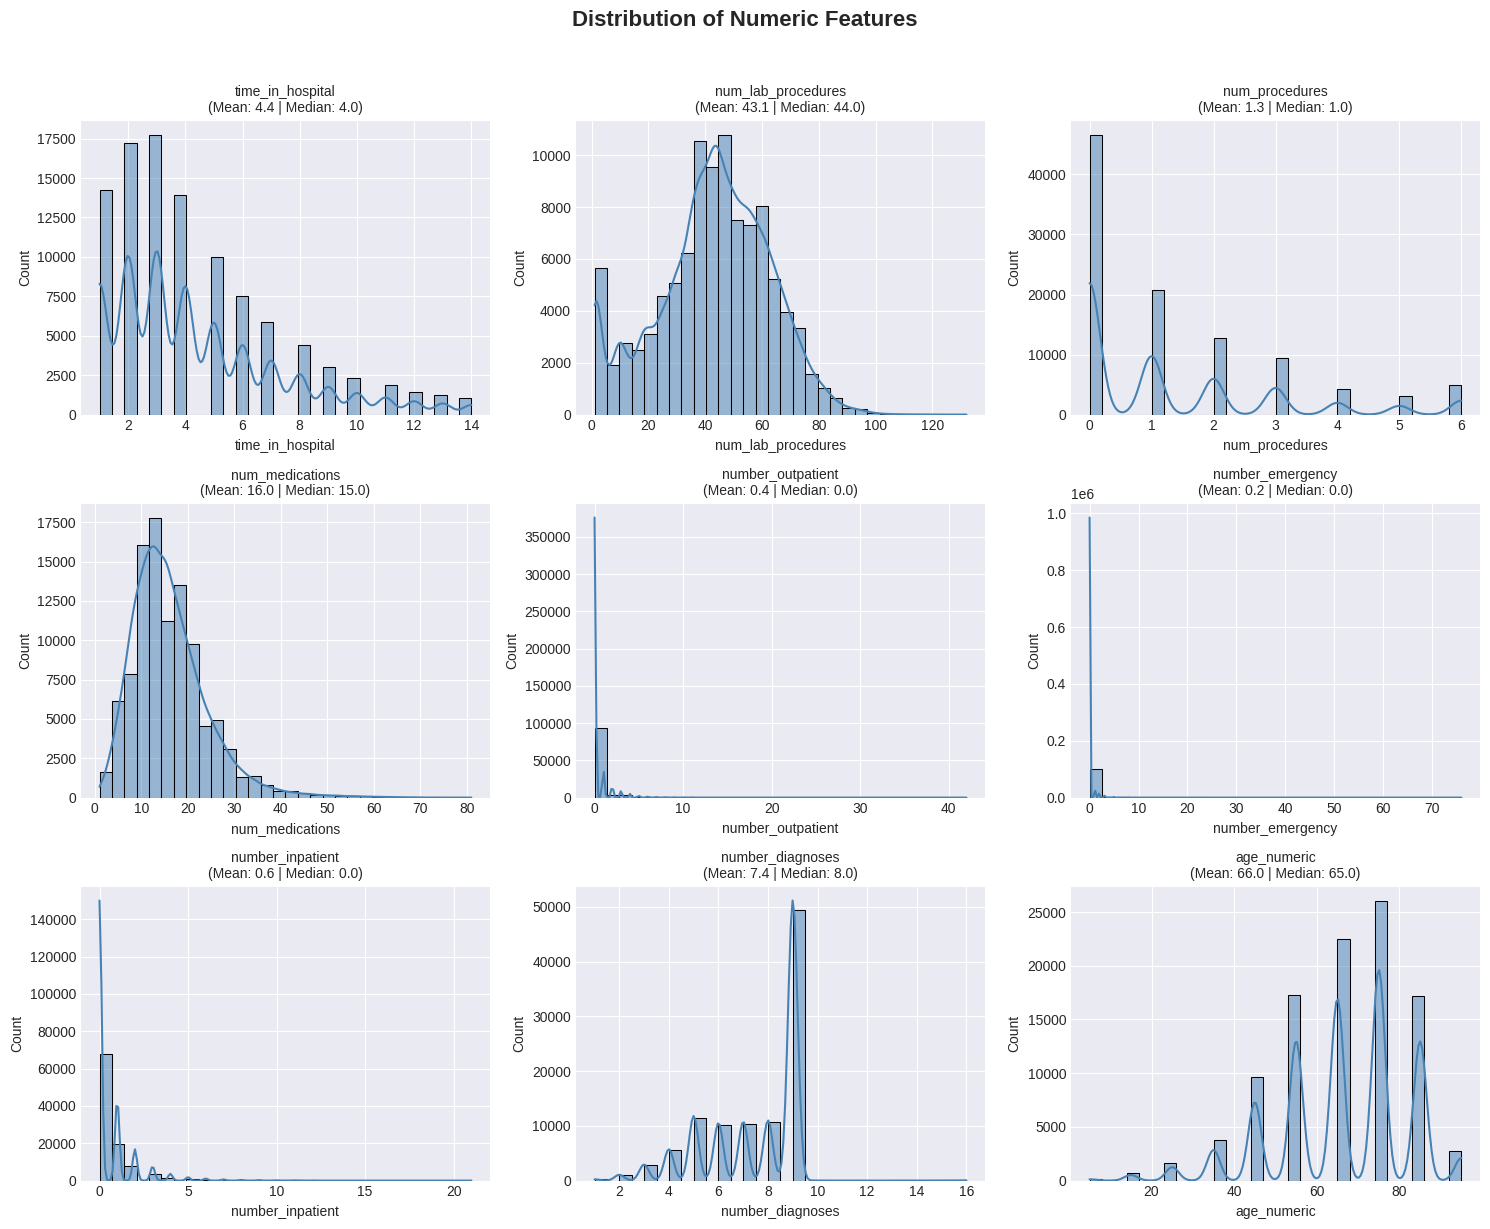


Statistical Summary:


,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,age_numeric
count,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00
mean,4.40,43.10,1.34,16.02,0.37,0.20,0.64,7.42,65.97
std,2.99,19.67,1.71,8.13,1.27,0.93,1.26,1.93,15.94
min,1.00,1.00,0.00,1.00,0.00,0.00,0.00,1.00,5.00
25%,2.00,31.00,0.00,10.00,0.00,0.00,0.00,6.00,55.00
50%,4.00,44.00,1.00,15.00,0.00,0.00,0.00,8.00,65.00
75%,6.00,57.00,2.00,20.00,0.00,0.00,1.00,9.00,75.00
max,14.00,132.00,6.00,81.00,42.00,76.00,21.00,16.00,95.00


In [11]:
# Plot Numeric Distributions
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
#suptitle while working on grid
fig.suptitle(
    "Distribution of Numeric Features", fontsize=16, fontweight="bold", y=1.02
)

# Zip automatically assigns each feature to the next available subplot
for ax, col in zip(axes.flat, numeric_features):
    if col in df.columns:
        sns.histplot(df[col], bins=30, ax=ax, color="steelblue", kde=True)
        ax.set_title(
            f"{col}\n(Mean: {df[col].mean():.1f} | Median: {df[col].median():.1f})",
            fontsize=10,
        )
        ax.set_ylabel("Count")

plt.tight_layout()
plt.savefig("visualizations/02_numeric_distributions.png", bbox_inches="tight")
plt.show()

print("\nStatistical Summary:")
display(df[numeric_features].describe().round(2)) # display() renders the df as clean , formatted HTML table.

#### Univariate Analysis: Categorical Features
Checking the distribution of demographics and clinical categories.**bold text**

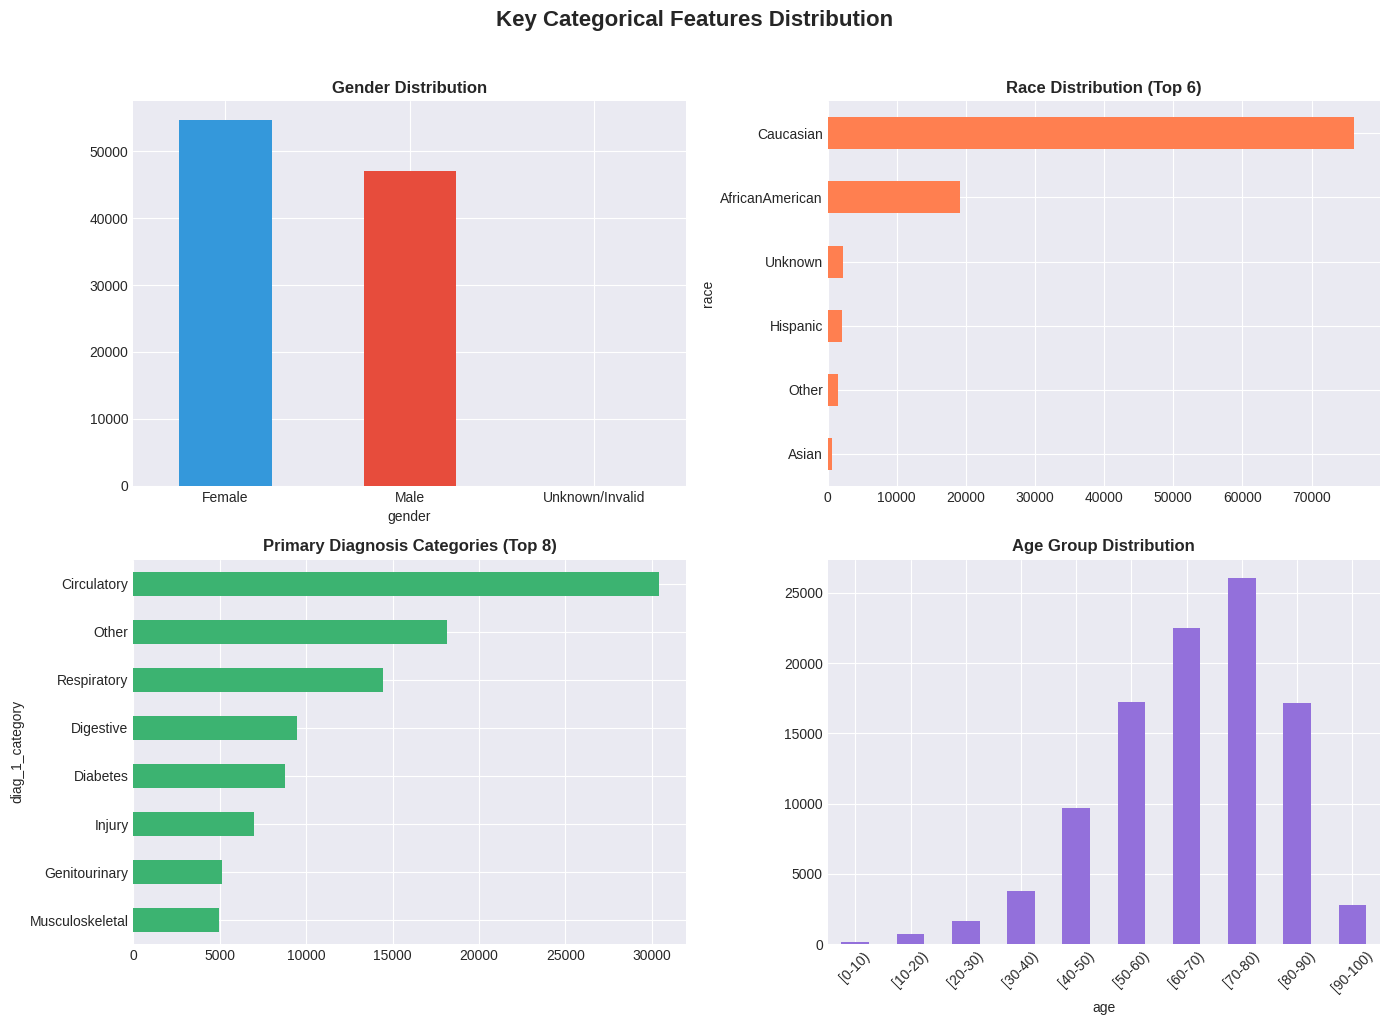

In [12]:
# Plot Categorical Distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10)) # draw a canvas(fig) 2x2 grid of 4 individual subplots(axes)
fig.suptitle('Key Categorical Features Distribution', fontsize=16, fontweight='bold', y=1.02)

# Gender
df['gender'].value_counts().plot(kind='bar', ax=axes[0, 0], color=['#3498db', '#e74c3c', '#95a5a6'], rot=0) # rot=0 for hoz. lables insted of tilted
axes[0, 0].set_title('Gender Distribution', fontweight='bold')

# Race (Top 6)
df['race'].value_counts().head(6).sort_values().plot(kind='barh', ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Race Distribution (Top 6)', fontweight='bold')

# Primary Diagnosis (Top 8)
df['diag_1_category'].value_counts().head(8).sort_values().plot(kind='barh', ax=axes[1, 0], color='mediumseagreen')
axes[1, 0].set_title('Primary Diagnosis Categories (Top 8)', fontweight='bold')

# Age Distribution (Sorted by age bracket)
df['age'].value_counts().sort_index().plot(kind='bar', ax=axes[1, 1], color='mediumpurple', rot=45) # sort_index() forces them into chronological_order insted of sorting most to less on freq basis
axes[1, 1].set_title('Age Group Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig('visualizations/03_categorical_distributions.png', bbox_inches='tight')
plt.show()

In [13]:
print(df["gender"].value_counts())

gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64


In [14]:
# droping the rows that are having Unknown/Invalid in gender column :
df = df[df['gender'] != 'Unknown/Invalid']
df.shape

(101763, 48)

- Fixed the gender column


#### Bivariate Analysis: Numeric Features vs Readmission
How do numerical metrics (like days in hospital or prior visits) differ between patients who are readmitted versus those who aren't?

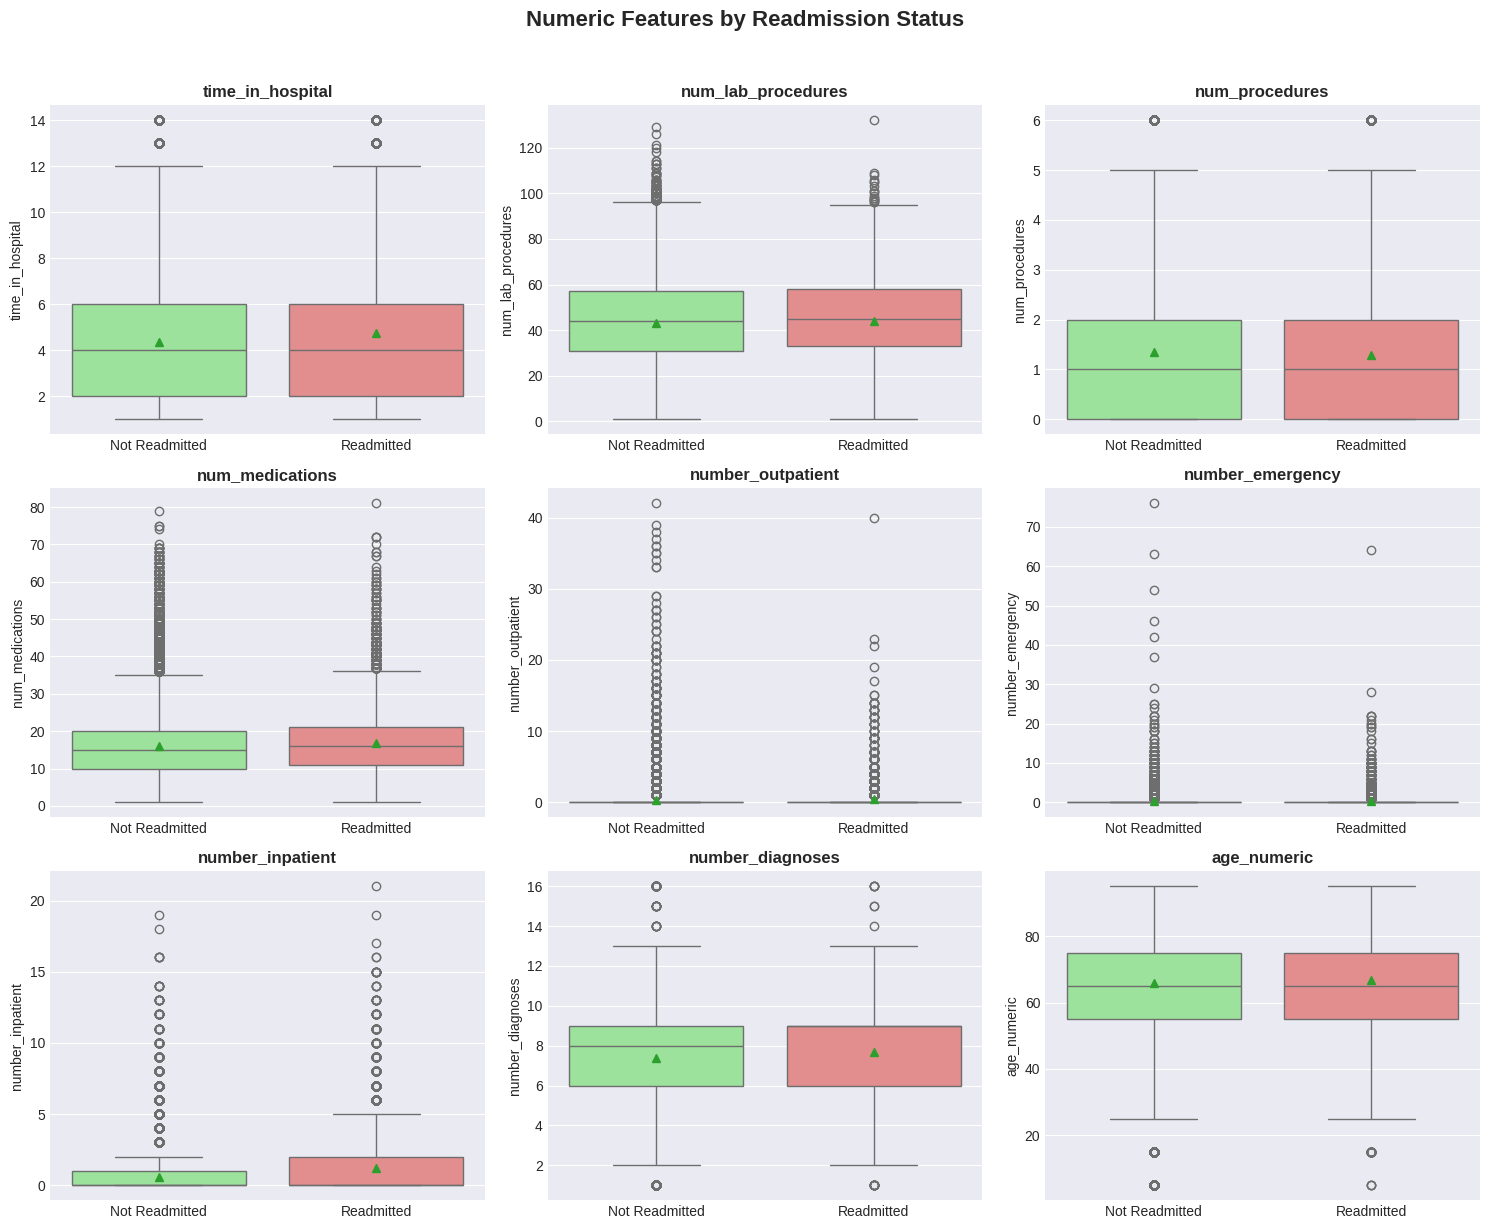

Mean Differences Between Readmitted (1) and Not Readmitted (0):
----------------------------------------------------------------------
time_in_hospital    : 4.35 vs 4.77 (+9.6%)
num_lab_procedures  : 42.95 vs 44.23 (+3.0%)
num_procedures      : 1.35 vs 1.28 (-4.9%)
num_medications     : 15.91 vs 16.90 (+6.2%)
number_outpatient   : 0.36 vs 0.44 (+21.1%)
number_emergency    : 0.18 vs 0.36 (+101.0%)
number_inpatient    : 0.56 vs 1.22 (+117.9%)
number_diagnoses    : 7.39 vs 7.69 (+4.1%)
age_numeric         : 65.87 vs 66.76 (+1.4%)


In [15]:
# Boxplots for Numeric Features by Readmission Status
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Numeric Features by Readmission Status', fontsize=16, fontweight='bold', y=1.02)

for ax, col in zip(axes.flat, numeric_features):
    if col in df.columns:
        sns.boxplot(data=df, x='readmitted_binary', y=col, ax=ax,
                    palette=['lightgreen', 'lightcoral'], showmeans=True)
        ax.set_title(col, fontweight='bold')
        ax.set_xticklabels(['Not Readmitted', 'Readmitted'])
        ax.set_xlabel('')

plt.tight_layout()
plt.savefig('visualizations/04_numeric_vs_readmission.png', bbox_inches='tight')
plt.show()

# Print out percentage differences
print("Mean Differences Between Readmitted (1) and Not Readmitted (0):")
print("-" * 70)
for col in numeric_features:
    mean_0 = df[df['readmitted_binary'] == 0][col].mean()
    mean_1 = df[df['readmitted_binary'] == 1][col].mean()
    pct_diff = ((mean_1 - mean_0) / mean_0 * 100) if mean_0 != 0 else 0
    print(f"{col.ljust(20)}: {mean_0:.2f} vs {mean_1:.2f} ({pct_diff:+.1f}%)")

In [16]:
# Readmission rate by gender and age — do demographics relate to risk?
print(df.groupby('gender')['readmitted_binary'].mean().mul(100).round(2))
print(df.groupby('readmitted_binary')['age_numeric'].agg(['mean', 'median']).round(1))

gender
Female    11.25
Male      11.06
Name: readmitted_binary, dtype: float64
                   mean  median
readmitted_binary              
0                  65.9    65.0
1                  66.8    65.0


  **Key Takeaways from Bivariate Numeric Analysis**
* **Prior Inpatient Visits are the #1 Risk Driver:** A massive **+117.9% increase** for readmitted patients. Frequent hospital users face the highest risk.
* **ER Utilization is a Major Red Flag:** Prior emergency visits jumped **+101.0%** among the readmitted group.
* **Sickness Severity vs. Treatment Length:** Readmitted patients had longer hospital stays (+9.6%) and managed more medications (+6.2%), whereas surgical procedures showed a slight decrease (-4.9%) due to structured post-op care.

#### Bivariate Analysis: Categorical Features vs Readmission
Identifying which patient subgroups (e.g., specific age groups or diagnoses) have the highest readmission rates.

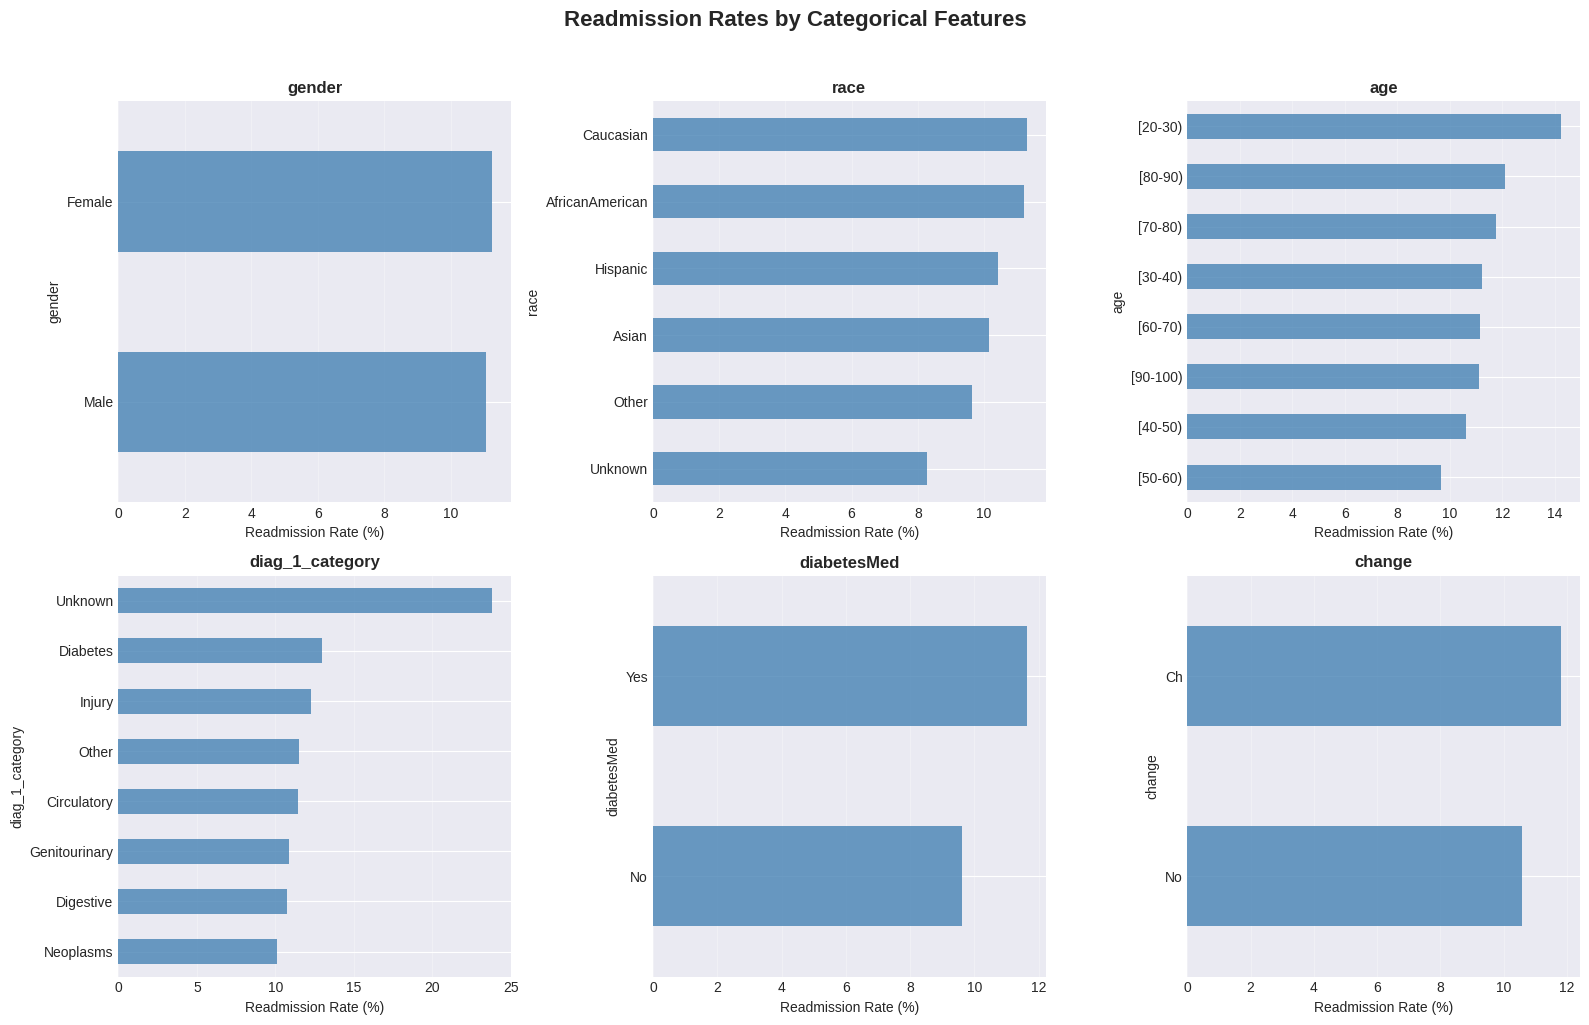

In [17]:
# Bar charts of Readmission Rates by Category
cat_features = ['gender', 'race', 'age', 'diag_1_category', 'diabetesMed', 'change']
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Readmission Rates by Categorical Features', fontsize=16, fontweight='bold', y=1.02)

for ax, col in zip(axes.flat, cat_features):
    if col in df.columns:
        # Calculate the mean of the binary target (which equals the % rate for readmitted ones)
        rates = df.groupby(col)['readmitted_binary'].mean().sort_values(ascending=True).tail(8) * 100
        rates.plot(kind='barh', ax=ax, color='steelblue', alpha=0.8)

        ax.set_title(col, fontweight='bold')
        ax.set_xlabel('Readmission Rate (%)')
        ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('visualizations/05_categorical_vs_readmission.png', bbox_inches='tight')
plt.show()

####  Correlation Analysis
Understanding which numerical variables are most strongly correlated with our target variable, and checking for multicollinearity between features.

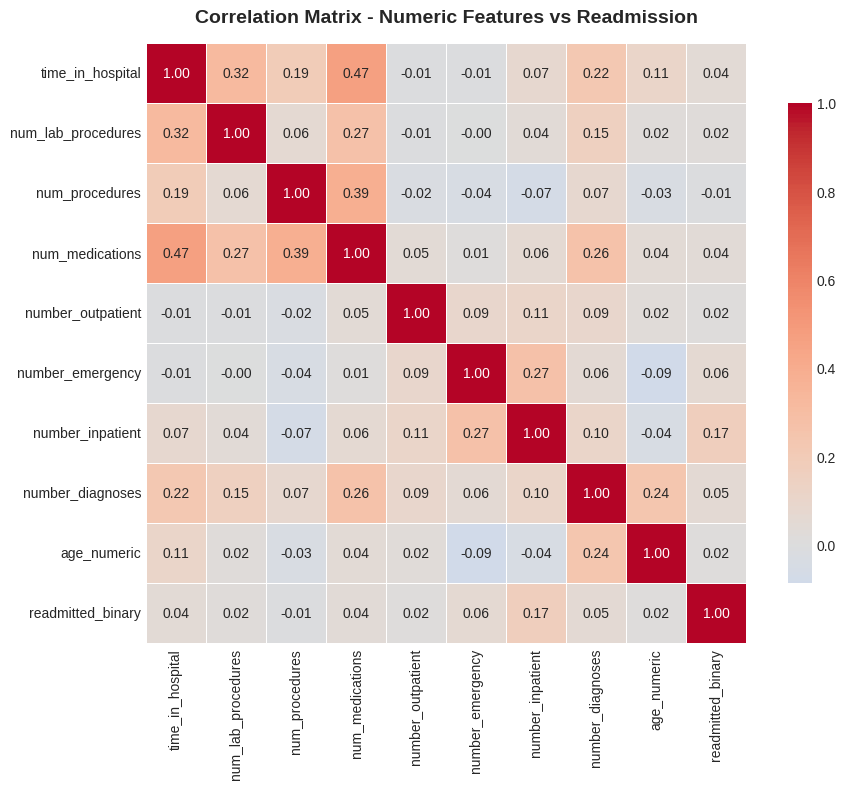


Top Correlations with Readmission Target:
--------------------------------------------------
number_inpatient      0.165143
number_emergency      0.060744
number_diagnoses      0.049518
time_in_hospital      0.044197
num_medications       0.038433
num_lab_procedures    0.020359
number_outpatient     0.018890
age_numeric           0.017638
num_procedures       -0.012219


In [18]:
# Correlation Matrix Heatmap
corr_columns = [col for col in numeric_features if col in df.columns] + ['readmitted_binary']
corr_matrix = df[corr_columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})

plt.title('Correlation Matrix - Numeric Features vs Readmission', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('visualizations/06_correlation_matrix.png', bbox_inches='tight')
plt.show()

# Extract and print top correlations specifically to the target variable
print("\nTop Correlations with Readmission Target:")
print("-" * 50)
target_corr = corr_matrix['readmitted_binary'].drop('readmitted_binary').sort_values(key=abs, ascending=False)
print(target_corr.to_string())

### READMISSION STATISTICS

In [19]:
total_patients = len(df)
readmitted_30 = (df['readmitted_binary'] == 1).sum()
readmission_rate = readmitted_30 / total_patients * 100

print(f"Overall 30-Day Readmission Rate: {readmission_rate:.2f}%")
print(f"Total Readmitted (< 30 days): {readmitted_30:,} out of {total_patients:,}")

Overall 30-Day Readmission Rate: 11.16%
Total Readmitted (< 30 days): 11,357 out of 101,763


## PREDICTIVE MODELING - DATA PREPARATION
Now we'll build machine learning models to predict 30-day readmission.
Steps:
1. Feature selection and encoding
2. Train-test split
3. Feature scaling
4. Model training and evaluation

In [20]:
# Feature Selection & Grouping

# Select features for modeling
# We'll use a mix of demographic, clinical, and administrative features

demographic_features = ["age_numeric", "gender", "race"]

clinical_features = [
    "time_in_hospital", "num_lab_procedures", "num_procedures",
    "num_medications", "number_diagnoses", "diag_1_category",
    "diag_2_category", "diag_3_category"
]

utilization_features = ["number_outpatient", "number_emergency", "number_inpatient"]

medication_features = ["diabetesMed", "change", "insulin", "metformin"]

# Combine all features
model_features = demographic_features + clinical_features + utilization_features + medication_features

# Safety check: Only keep features that actually exist in our dataframe
model_features = [f for f in model_features if f in df.columns]

print(f"Total features selected for modeling: {len(model_features)}")

Total features selected for modeling: 18


In [21]:
# Create Modeling Dataset (X and y)

# Create a clean copy with only our selected features and the target
df_model = df[model_features + ["readmitted_binary"]].copy()

# Separate features (X) and target (y)
X = df_model[model_features].copy()
y = df_model["readmitted_binary"].copy()

print(f"Feature matrix (X) shape: {X.shape}")
print(f"Target vector (y) shape: {y.shape}")

Feature matrix (X) shape: (101763, 18)
Target vector (y) shape: (101763,)


### Encoding

- Checking the Features to find which encoding suites them like
- Ordinal or (0/1) than -> Label Encoding
- Nominal Than -> One-Hot Encoding



In [22]:
# 1. Select only the text/categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"Total Categorical Features: {len(categorical_cols)}\n")
print("-" * 50)

for col in categorical_cols:
    unique_vals = X[col].unique()
    num_vals = X[col].nunique()

    print(f"Feature: **{col}**")
    print(f"Total Categories: {num_vals}")
    print(f"Values: {unique_vals}")
    print("-" * 50)

Total Categorical Features: 9

--------------------------------------------------
Feature: **gender**
Total Categories: 2
Values: ['Female' 'Male']
--------------------------------------------------
Feature: **race**
Total Categories: 6
Values: ['Caucasian' 'AfricanAmerican' 'Unknown' 'Other' 'Asian' 'Hispanic']
--------------------------------------------------
Feature: **diag_1_category**
Total Categories: 10
Values: ['Diabetes' 'Other' 'Neoplasms' 'Circulatory' 'Respiratory' 'Injury'
 'Musculoskeletal' 'Digestive' 'Genitourinary' 'Unknown']
--------------------------------------------------
Feature: **diag_2_category**
Total Categories: 10
Values: ['Unknown' 'Diabetes' 'Neoplasms' 'Circulatory' 'Respiratory' 'Other'
 'Injury' 'Musculoskeletal' 'Genitourinary' 'Digestive']
--------------------------------------------------
Feature: **diag_3_category**
Total Categories: 10
Values: ['Unknown' 'Other' 'Circulatory' 'Diabetes' 'Respiratory' 'Injury'
 'Neoplasms' 'Genitourinary' 'Musculos

--- Readmission Rates by insulin Level ---
insulin
No        10.04%
Down       13.9%
Steady    11.13%
Up        12.99%
Name: readmitted_binary, dtype: object

--- Readmission Rates by metformin Level ---
metformin
No        11.52%
Down       12.0%
Steady     9.71%
Up         8.25%
Name: readmitted_binary, dtype: object



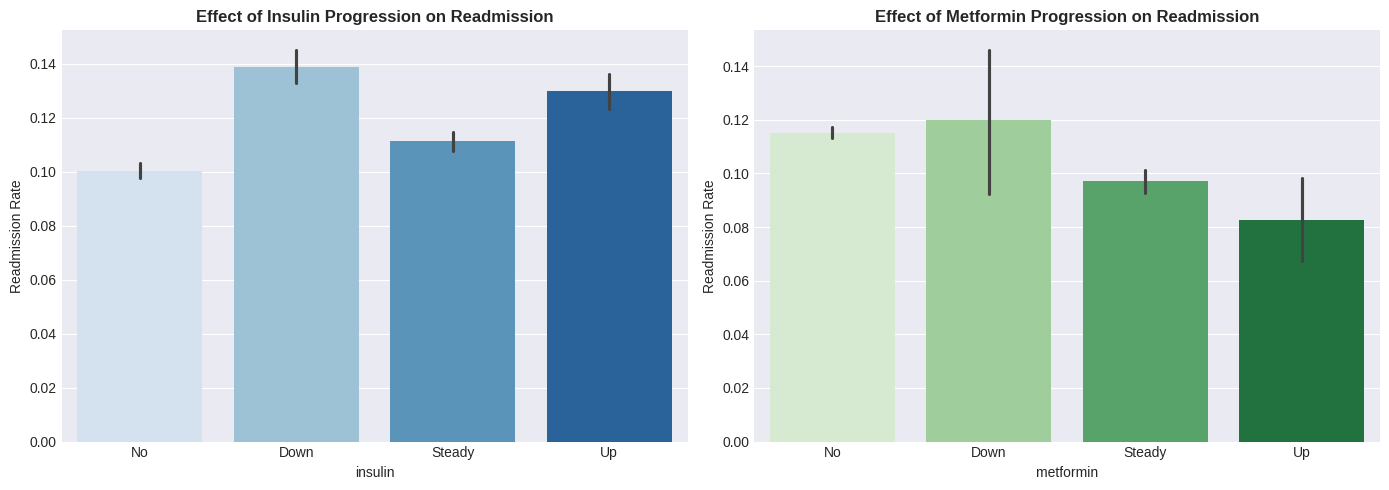

In [23]:
# Checking the fetures insuline and metformin for finding whether they were Nominal Or Ordinal

#  Calculate the raw readmission rates for both medications columns (insulin and metformin)
med_order = ['No', 'Down', 'Steady', 'Up']

for med in ['insulin', 'metformin']:
    rates = df.groupby(med)['readmitted_binary'].mean() * 100
    print(f"--- Readmission Rates by {med} Level ---")
    # Reindex to force our logical ordinal progression
    print(rates.reindex(med_order).round(2).astype(str) + '%')
    print()

#  Visualize the trend
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df, x='insulin', y='readmitted_binary', order=med_order, ax=axes[0], palette='Blues')
axes[0].set_title('Effect of Insulin Progression on Readmission', fontweight='bold')
axes[0].set_ylabel('Readmission Rate')

sns.barplot(data=df, x='metformin', y='readmitted_binary', order=med_order, ax=axes[1], palette='Greens')
axes[1].set_title('Effect of Metformin Progression on Readmission', fontweight='bold')
axes[1].set_ylabel('Readmission Rate')

plt.tight_layout()
plt.savefig('visualizations/07_insuline_and_matformin_columns_categories_test.png', bbox_inches='tight')
plt.show()

- insulin and metformin doesn't have a specific order so we will consider these features as 'Nominal'

In [24]:
# Encoding
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

binary_cols = ['gender', 'diabetesMed', 'change']
nominal_cols = ['race', 'diag_1_category', 'diag_2_category', 'diag_3_category', 'insulin', 'metformin']

# label encoding
le = LabelEncoder()
for col in binary_cols:
  X[col] = le.fit_transform(X[col].astype(str))

# one-hot encoding
ohe = OneHotEncoder(drop='first', sparse_output=False)
encoded_array = ohe.fit_transform(X[nominal_cols])

encoded_df = pd.DataFrame(
    encoded_array,
    columns=ohe.get_feature_names_out(nominal_cols),
    index=X.index
)

X = X.drop(columns=nominal_cols).join(encoded_df)

print(f"Encoding complete! Final shape of X: {X.shape}")

Encoding complete! Final shape of X: (101763, 50)


### Test-Train Split & Feature Scaling

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # stratify forces test train split to maintain same ration in the testing and training

print(f"Training set size: {X_train.shape[0]:,}")
print(f"Testing set size: {X_test.shape[0]:,}")



Training set size: 81,410
Testing set size: 20,353


In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled , columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled , columns=X.columns, index=X_test.index)

print("Data successfully split and scaled!")

Data successfully split and scaled!


### BaseLine Model **("Logistic Regression")**

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


lr_model = LogisticRegression(max_iter=1000 , class_weight='balanced' , random_state=42)
lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)
lr_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]


print(f"ROC-AUC Score: {roc_auc_score(y_test, lr_pred_proba):.4f}\n")
print(classification_report(y_test, lr_pred , target_names=['Not Readmitted', 'Readmitted']))

ROC-AUC Score: 0.6451

                precision    recall  f1-score   support

Not Readmitted       0.92      0.68      0.78     18082
    Readmitted       0.17      0.53      0.26      2271

      accuracy                           0.67     20353
     macro avg       0.55      0.61      0.52     20353
  weighted avg       0.84      0.67      0.73     20353



### Random Forest


In [28]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1 # Uses all processor cores to speed up training
)

rf_model.fit(X_train_scaled, y_train)

rf_pred = rf_model.predict(X_test_scaled)
rf_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

print(f"ROC-AUC Score: {roc_auc_score(y_test, rf_pred_proba):.4f}\n")
print(classification_report(y_test, rf_pred, target_names=['Not Readmitted', 'Readmitted']))

ROC-AUC Score: 0.6327

                precision    recall  f1-score   support

Not Readmitted       0.90      0.87      0.89     18082
    Readmitted       0.21      0.27      0.23      2271

      accuracy                           0.80     20353
     macro avg       0.55      0.57      0.56     20353
  weighted avg       0.83      0.80      0.81     20353



### XGBOOST


In [29]:
from xgboost import XGBClassifier

# scale_pos_weight handles imbalance the way class_weight='balanced' does for LR/RF
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train_scaled, y_train)

xgb_pred = xgb_model.predict(X_test_scaled)
xgb_pred_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

print(f"ROC-AUC Score: {roc_auc_score(y_test, xgb_pred_proba):.4f}\n")
print(classification_report(y_test, xgb_pred, target_names=['Not Readmitted', 'Readmitted']))

ROC-AUC Score: 0.6526

                precision    recall  f1-score   support

Not Readmitted       0.92      0.66      0.77     18082
    Readmitted       0.17      0.57      0.26      2271

      accuracy                           0.65     20353
     macro avg       0.55      0.61      0.52     20353
  weighted avg       0.84      0.65      0.71     20353



## Model Comparison
- Here Recall (FN) and ROC-AUC Score is more important

In [30]:
models_results = {
    'Logistic Regression': (lr_pred, lr_pred_proba),
    'Random Forest': (rf_pred, rf_pred_proba),
    'XGBoost': (xgb_pred, xgb_pred_proba),
}

comparison = pd.DataFrame({
    name: {
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1': f1_score(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, proba),
    }
    for name, (pred, proba) in models_results.items()
}).T.round(4)

comparison

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.6669,0.1747,0.5332,0.2632,0.6451
Random Forest,0.8025,0.2053,0.2682,0.2325,0.6327
XGBoost,0.6459,0.1717,0.5685,0.2637,0.6526


In [31]:
# Accuracy is misleading with 11.16% positive class — a model predicting "no"
# for everyone Recall and ROC-AUC are the deciding metrics here,
# since a missed readmission (FN) costs far more than a false alarm (FP).
best_recall = comparison['Recall'].idxmax()
best_auc = comparison['ROC-AUC'].idxmax()

print(f"Best Recall: {best_recall} ({comparison.loc[best_recall, 'Recall']:.2f})")
print(f"Best ROC-AUC: {best_auc} ({comparison.loc[best_auc, 'ROC-AUC']:.4f})")

Best Recall: XGBoost (0.57)
Best ROC-AUC: XGBoost (0.6526)


In [37]:
cost_readmission = 15000
cost_intervention = 1000
effectiveness = 0.70

def cost_benefit_summary(y_test, y_pred, model_name):
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()


    prevented = tp * effectiveness
    intervention_cost = (tp + fp) * cost_intervention
    savings = prevented * cost_readmission
    net_benefit = savings - intervention_cost

    return {'Model': model_name, 'Caught (TP)': tp, 'Missed (FN)': fn,
            'False Alarms (FP)': fp, 'Net Benefit ($)': net_benefit}


cost_results = pd.DataFrame([
    cost_benefit_summary(y_test, lr_pred, 'Logistic Regression'),
    cost_benefit_summary(y_test, rf_pred, 'Random Forest'),
    cost_benefit_summary(y_test, xgb_pred, 'XGBoost'),
]).set_index('Model')

cost_results

,Caught (TP),Missed (FN),False Alarms (FP),Net Benefit ($)
Model,,,,
Logistic Regression,1211,1060,5719,5785500.0
Random Forest,609,1662,2358,3427500.0
XGBoost,1291,980,6228,6036500.0


In [38]:
best_model = comparison['ROC-AUC'].idxmax()
best_net = cost_results['Net Benefit ($)'].idxmax()

print(f"{best_model} has the strongest recall and ROC-AUC — it catches the most "
      f"at-risk patients and ranks risk most reliably.")
print(f"{best_net} produces the highest estimated net benefit under the "
      f"assumed cost model (${cost_readmission:,} per readmission, "
      f"${cost_intervention:,} per intervention).")
print(f"\nAll three models sit in a tight ROC-AUC band ({comparison['ROC-AUC'].min():.3f}–"
      f"{comparison['ROC-AUC'].max():.3f}), suggesting the ceiling here is set by "
      f"available features rather than model choice.")

XGBoost has the strongest recall and ROC-AUC — it catches the most at-risk patients and ranks risk most reliably.
XGBoost produces the highest estimated net benefit under the assumed cost model ($15,000 per readmission, $1,000 per intervention).

All three models sit in a tight ROC-AUC band (0.633–0.653), suggesting the ceiling here is set by available features rather than model choice.


## Model Evaluation — Visuals

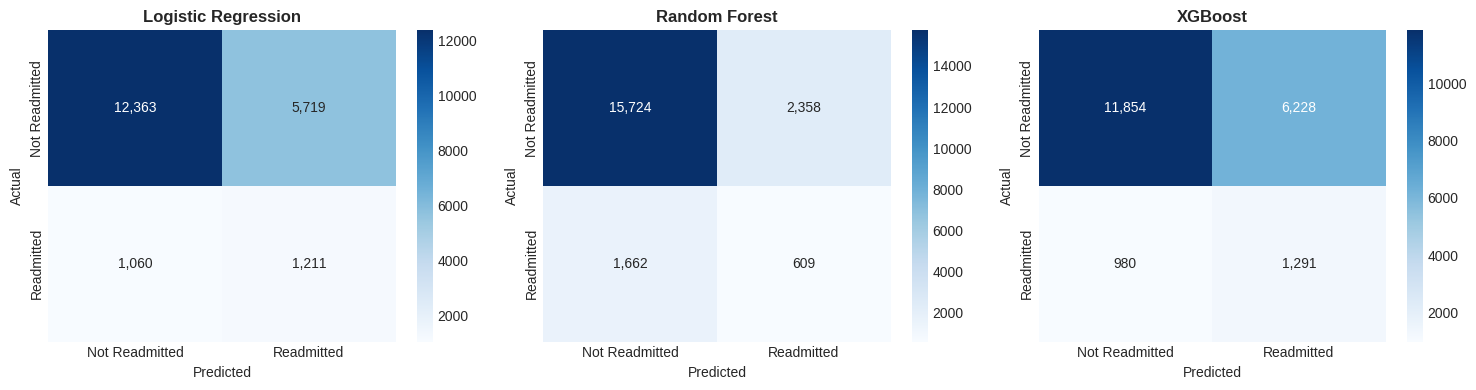

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, (pred, _)) in zip(axes, models_results.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', ax=ax,
                xticklabels=['Not Readmitted', 'Readmitted'],
                yticklabels=['Not Readmitted', 'Readmitted'])
    ax.set_title(name, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('visualizations/08_confusion_matrices_all.png', dpi=300, bbox_inches='tight')
plt.show()

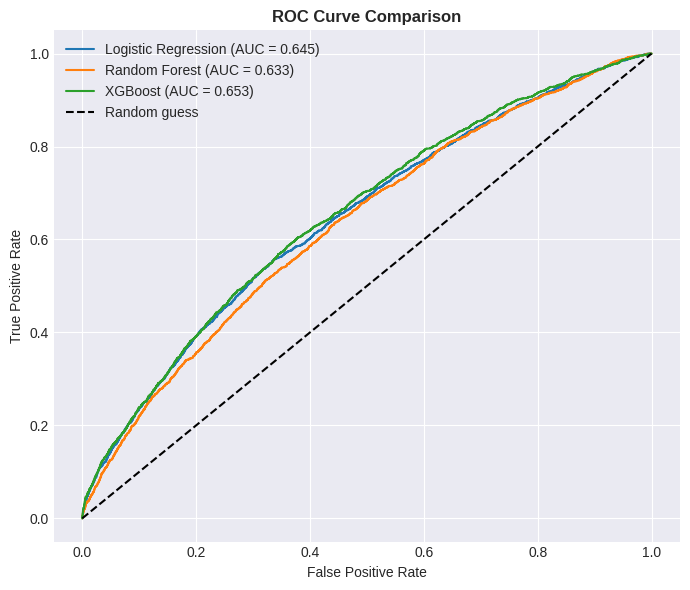

In [40]:
plt.figure(figsize=(7, 6))

for name, (_, proba) in models_results.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('visualizations/09_roc_curve_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

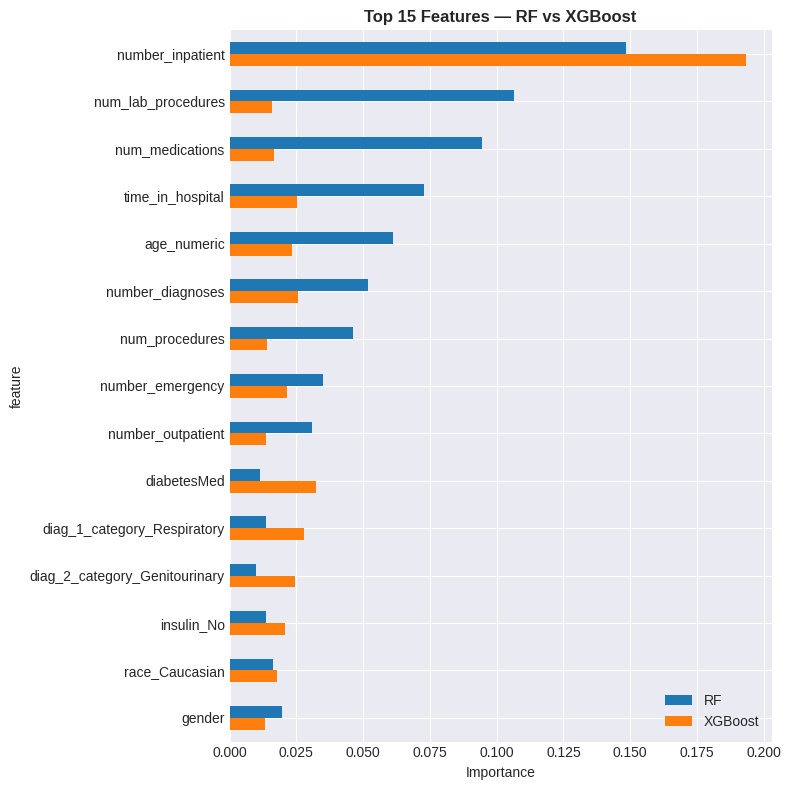

In [41]:
importance_df = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'RF': rf_model.feature_importances_,
    'XGBoost': xgb_model.feature_importances_,
}).set_index('feature')

top_features = importance_df.sum(axis=1).sort_values(ascending=False).head(15).index
importance_df.loc[top_features].plot(kind='barh', figsize=(8, 8))
plt.title('Top 15 Features — RF vs XGBoost', fontweight='bold')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('visualizations/10_feature_importance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

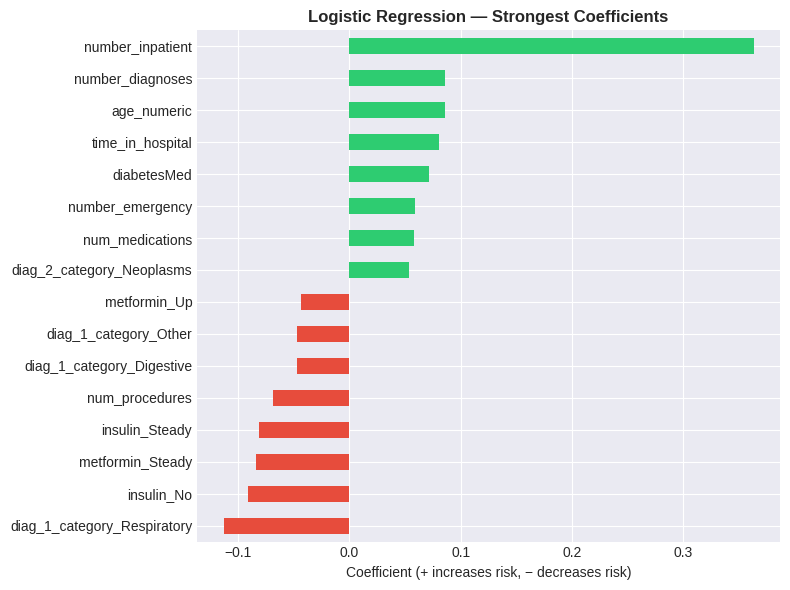

In [42]:
coef_df = pd.Series(lr_model.coef_[0], index=X_train_scaled.columns).sort_values()
top_coef = pd.concat([coef_df.head(8), coef_df.tail(8)])

top_coef.plot(kind='barh', figsize=(8, 6), color=['#e74c3c' if c < 0 else '#2ecc71' for c in top_coef])
plt.title('Logistic Regression — Strongest Coefficients', fontweight='bold')
plt.xlabel('Coefficient (+ increases risk, − decreases risk)')
plt.tight_layout()
plt.savefig('visualizations/11_lr_coefficients.png', dpi=300, bbox_inches='tight')
plt.show()

For the Best Model

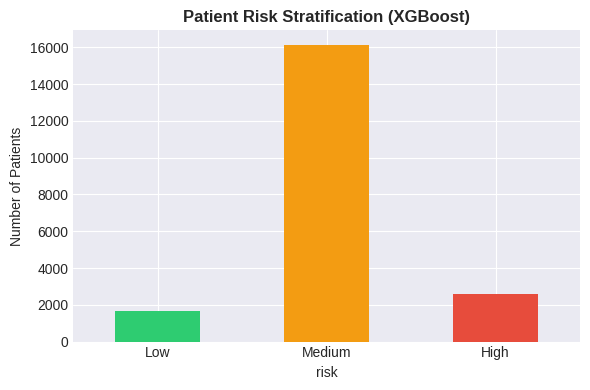

,Patients,Actual Readmit Rate
risk,,
Low,1638,0.044567
Medium,16118,0.100819
High,2597,0.220639


In [43]:
best_name = comparison['ROC-AUC'].idxmax()
best_proba = models_results[best_name][1]

risk_bins = pd.cut(best_proba, bins=[0, 0.3, 0.6, 1.0], labels=['Low', 'Medium', 'High'])
risk_summary = pd.DataFrame({'risk': risk_bins, 'actual': y_test.values}).groupby('risk')['actual'].agg(['count', 'mean'])
risk_summary.columns = ['Patients', 'Actual Readmit Rate']

risk_summary['Patients'].plot(kind='bar', figsize=(6, 4), color=['#2ecc71', '#f39c12', '#e74c3c'])
plt.title(f'Patient Risk Stratification ({best_name})', fontweight='bold')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('visualizations/12_risk_stratification.png', dpi=300, bbox_inches='tight')
plt.show()

risk_summary

## Executive Summary

In [44]:
best_model = comparison['ROC-AUC'].idxmax()
best_row = comparison.loc[best_model]
best_cost_row = cost_results.loc[best_model]

print(f"Best model: {best_model}")
print(best_row)
print(best_cost_row)

Best model: XGBoost
Accuracy     0.6459
Precision    0.1717
Recall       0.5685
F1           0.2637
ROC-AUC      0.6526
Name: XGBoost, dtype: float64
Caught (TP)             1291.0
Missed (FN)              980.0
False Alarms (FP)       6228.0
Net Benefit ($)      6036500.0
Name: XGBoost, dtype: float64


In [45]:
summary_report = f"""
HEALTHCARE READMISSION PREDICTION — EXECUTIVE SUMMARY

PROJECT OVERVIEW
Objective: Predict 30-day hospital readmissions for diabetes patients
Dataset: Diabetes 130-US Hospitals (1999-2008)
Total Records: {len(df):,}

KEY FINDINGS
1. Readmission rate: {readmission_rate:.2f}% ({readmitted_30:,} of {len(df):,} patients)
2. Model comparison (Logistic Regression, Random Forest, XGBoost) — see comparison table
3. Best model: {best_model}
   - Recall: {best_row['Recall']:.2%}
   - ROC-AUC: {best_row['ROC-AUC']:.4f}
   - Accuracy: {best_row['Accuracy']:.2%} (secondary metric — misleading alone given class imbalance)

WHY {best_model.upper()}, NOT JUST HIGHEST ACCURACY
Accuracy favors the majority class (88.84% not readmitted), so a model can
score well while missing most at-risk patients. Recall and ROC-AUC were
prioritized instead, since a missed readmission (false negative) costs far
more than an unnecessary follow-up (false positive).

CONFUSION MATRIX — {best_model}
Caught (TP): {best_cost_row['Caught (TP)']:,}
Missed (FN): {best_cost_row['Missed (FN)']:,}
False alarms (FP): {best_cost_row['False Alarms (FP)']:,}

BUSINESS IMPACT (hypothetical cost model)
Assumptions: ${cost_readmission:,} per readmission, ${cost_intervention:,} per
intervention, 70% intervention effectiveness
Net benefit: ${best_cost_row['Net Benefit ($)']:,.0f}

LIMITATIONS
ROC-AUC across all three models sits in a narrow 0.63–0.65 band, indicating
the ceiling here is set by available features (demographics, utilization)
rather than model choice. Richer clinical data — lab results, medication
history detail — would likely yield larger gains than further model tuning.
"""

print(summary_report)

with open('EXECUTIVE_SUMMARY.txt', 'w') as f:
    f.write(summary_report)


HEALTHCARE READMISSION PREDICTION — EXECUTIVE SUMMARY

PROJECT OVERVIEW
Objective: Predict 30-day hospital readmissions for diabetes patients
Dataset: Diabetes 130-US Hospitals (1999-2008)
Total Records: 101,763

KEY FINDINGS
1. Readmission rate: 11.16% (11,357 of 101,763 patients)
2. Model comparison (Logistic Regression, Random Forest, XGBoost) — see comparison table
3. Best model: XGBoost
   - Recall: 56.85%
   - ROC-AUC: 0.6526
   - Accuracy: 64.59% (secondary metric — misleading alone given class imbalance)

WHY XGBOOST, NOT JUST HIGHEST ACCURACY
Accuracy favors the majority class (88.84% not readmitted), so a model can
score well while missing most at-risk patients. Recall and ROC-AUC were
prioritized instead, since a missed readmission (false negative) costs far
more than an unnecessary follow-up (false positive).

CONFUSION MATRIX — XGBoost
Caught (TP): 1,291.0
Missed (FN): 980.0
False alarms (FP): 6,228.0

BUSINESS IMPACT (hypothetical cost model)
Assumptions: $15,000 per rea

## Final Dashboard

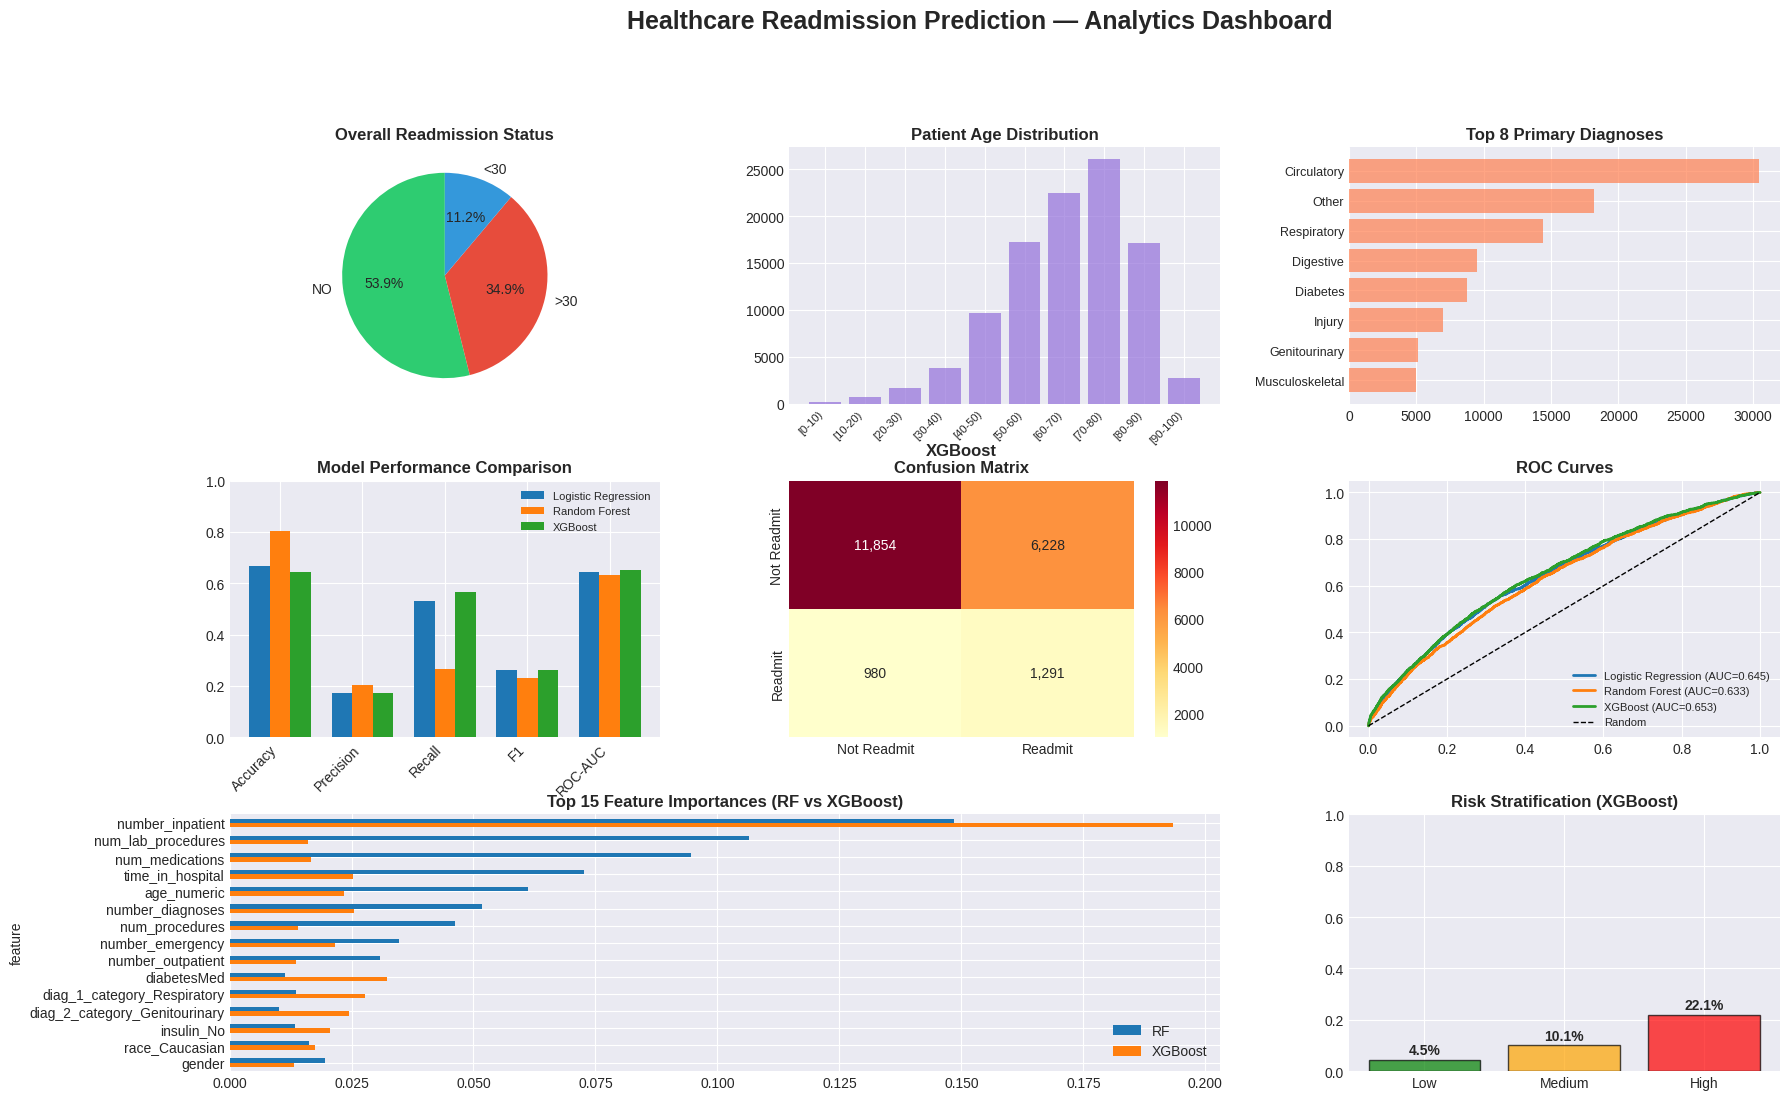

In [46]:
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Readmission status
ax1 = fig.add_subplot(gs[0, 0])
readmit_counts = df['readmitted'].value_counts()
ax1.pie(readmit_counts.values, labels=readmit_counts.index, autopct='%1.1f%%',
        colors=['#2ecc71', '#e74c3c', '#3498db'], startangle=90)
ax1.set_title('Overall Readmission Status', fontweight='bold', fontsize=12)

# 2. Age distribution
ax2 = fig.add_subplot(gs[0, 1])
age_order = sorted(df['age'].unique())
age_data = df['age'].value_counts().reindex(age_order)
ax2.bar(range(len(age_data)), age_data.values, color='mediumpurple', alpha=0.7)
ax2.set_xticks(range(len(age_data)))
ax2.set_xticklabels(age_data.index, rotation=45, ha='right', fontsize=8)
ax2.set_title('Patient Age Distribution', fontweight='bold', fontsize=12)

# 3. Top diagnoses
ax3 = fig.add_subplot(gs[0, 2])
top_diag = df['diag_1_category'].value_counts().head(8)
ax3.barh(range(len(top_diag)), top_diag.values, color='coral', alpha=0.7)
ax3.set_yticks(range(len(top_diag)))
ax3.set_yticklabels(top_diag.index, fontsize=9)
ax3.set_title('Top 8 Primary Diagnoses', fontweight='bold', fontsize=12)
ax3.invert_yaxis()

# 4. Model performance — all three models, grouped bars
ax4 = fig.add_subplot(gs[1, 0])
x = np.arange(len(comparison.columns))
width = 0.25
for i, (name, row) in enumerate(comparison.iterrows()):
    ax4.bar(x + (i - 1) * width, row.values, width, label=name)
ax4.set_xticks(x)
ax4.set_xticklabels(comparison.columns, rotation=45, ha='right')
ax4.set_ylim([0, 1])
ax4.set_title('Model Performance Comparison', fontweight='bold', fontsize=12)
ax4.legend(fontsize=8)

# 5. Confusion matrix — best model only
ax5 = fig.add_subplot(gs[1, 1])
best_model = comparison['ROC-AUC'].idxmax()
best_pred = models_results[best_model][0]
cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt=',', cmap='YlOrRd', ax=ax5,
            xticklabels=['Not Readmit', 'Readmit'], yticklabels=['Not Readmit', 'Readmit'])
ax5.set_title(f'{best_model}\nConfusion Matrix', fontweight='bold', fontsize=12)

# 6. ROC curves — all three
ax6 = fig.add_subplot(gs[1, 2])
for name, (_, proba) in models_results.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax6.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test, proba):.3f})', linewidth=2)
ax6.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
ax6.set_title('ROC Curves', fontweight='bold', fontsize=12)
ax6.legend(loc='lower right', fontsize=8)

# 7. Feature importance — RF + XGBoost (tree-based models only)
ax7 = fig.add_subplot(gs[2, :2])
top_15 = importance_df.sum(axis=1).sort_values(ascending=False).head(15).index
importance_df.loc[top_15].plot(kind='barh', ax=ax7)
ax7.set_title('Top 15 Feature Importances (RF vs XGBoost)', fontweight='bold', fontsize=12)
ax7.invert_yaxis()

# 8. Risk stratification — best model
ax8 = fig.add_subplot(gs[2, 2])
ax8.bar(risk_summary.index, risk_summary['Actual Readmit Rate'],
        color=['green', 'orange', 'red'], alpha=0.7, edgecolor='black')
ax8.set_title(f'Risk Stratification ({best_model})', fontweight='bold', fontsize=12)
ax8.set_ylim([0, 1])
for i, v in enumerate(risk_summary['Actual Readmit Rate']):
    ax8.text(i, v + 0.02, f'{v*100:.1f}%', ha='center', fontweight='bold')

fig.suptitle('Healthcare Readmission Prediction — Analytics Dashboard', fontsize=18, fontweight='bold', y=0.995)
plt.savefig('visualizations/13_FINAL_DASHBOARD.png', dpi=300, bbox_inches='tight')
plt.show()

## Final Results and Conclusion

We evaluated three classification models — Logistic Regression, Random Forest, and XGBoost — for predicting 30-day hospital readmissions in diabetes patients, using a dataset of 101,763 records with an 11.16% readmission rate.

Because of this class imbalance, we prioritized **recall** and **ROC-AUC** over raw accuracy. Accuracy alone is misleading here: a model can score well simply by predicting "not readmitted" for most patients, while missing the exact cases the project is meant to catch. In a healthcare setting, a missed readmission (false negative) is far more costly than an unnecessary follow-up call (false positive), so recall was treated as the primary evaluation metric.

**Results:**

| Model | Recall | ROC-AUC | Accuracy |
|---|---|---|---|
| Logistic Regression | 0.53 | 0.6451 | 0.67 |
| Random Forest | 0.27 | 0.6327 | 0.80 |
| XGBoost | 0.57 | 0.6526 | 0.65 |

Random Forest had the highest accuracy, but this was driven by the class imbalance rather than genuine predictive strength — it correctly identified low-risk patients but missed the majority of actual readmissions. XGBoost achieved the strongest recall and ROC-AUC, correctly identifying the most at-risk patients while maintaining the best overall discrimination between classes.

**XGBoost was selected as the final model** based on these results.

The ROC-AUC scores across all three models fall within a relatively narrow range (0.63–0.65), indicating that the predictive ceiling is largely determined by the available features — patient demographics and hospital utilization history — rather than model choice. Incorporating richer clinical data, such as lab results, would likely improve performance further.

From a business standpoint, the model identifies a manageable subset of patients for targeted intervention at discharge. Given that the cost of a missed readmission substantially exceeds the cost of an unnecessary follow-up, this trade-off supports deployment as a discharge-planning support tool rather than a fully automated decision system.